In [1]:
import os, json, pickle
import numpy as np
import torch
from torch.utils.data import DataLoader
from go_ml.data_utils import *

train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
with open(f"{train_path}/cafa_dataset/prot_ids.json", "r") as f:
    prot_ids = json.load(f)
with open(f"{train_path}/cafa_dataset/rev_annot.pkl", "rb") as f:
    labels = pickle.load(f)
print((np.asarray(labels.sum(axis=1)) > 0).sum() / labels.shape[0])
prot_sequences, seq_ids = load_protein_sequences(f"{train_path}/uniprot_sprot.fasta")

assert all(s1 == s2 for s1, s2 in zip(prot_ids, seq_ids))
labeled_id = (np.asarray(labels.sum(axis=1)) > 0).flatten()

gen = np.random.default_rng(seed=42)
ind = gen.permuted(np.arange(len(prot_ids))[labeled_id])
train_len = ind.shape[0] * 4 // 5
train_ind = ind[:train_len]
val_ind = ind[train_len:]
np.sort(train_ind); np.sort(val_ind)
train_ids = [prot_ids[i] for i in train_ind]; train_sequences = [prot_sequences[i] for i in train_ind]
val_ids = [prot_ids[i] for i in val_ind]; val_sequences = [prot_sequences[i] for i in val_ind]
train_labels = labels[train_ind, :]; val_labels = labels[val_ind, :]
train_dataset = BertSeqDataset(train_ids, go_terms, train_sequences, train_labels)
val_dataset = BertSeqDataset(val_ids, go_terms, val_sequences, val_labels)
print(f"train len {len(train_dataset)} val len {len(val_dataset)}")

# from Bio import SeqIO
# from Bio.Seq import Seq
# from Bio.SeqRecord import SeqRecord

# train_seq = [SeqRecord(Seq(seq.upper()), id=prot_id) for seq, prot_id in zip(train_sequences, train_ids)]
# with open("../../data/train_seq.fasta", "w") as f:
#     SeqIO.write(train_seq, f, 'fasta')

0.27317815417177815
train len 124524 val len 31131


In [2]:
import pandas as pd
train_similarity = pd.read_csv("../../data/dblast_data/train_crossmatches.tsv", sep='\t', header=None)

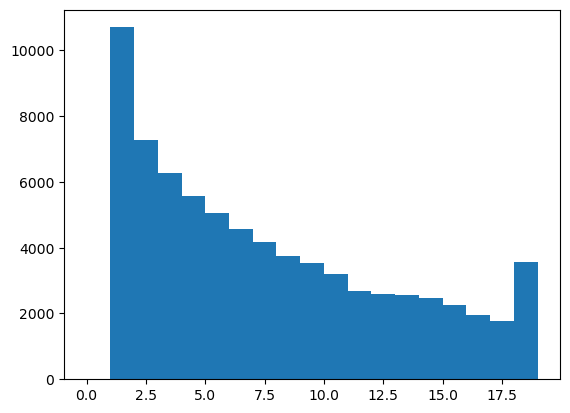

In [4]:
from collections import Counter
hit_num = Counter(train_similarity[train_similarity[10] < 0.01][0])
import matplotlib.pyplot as plt
plt.hist(hit_num.values(), bins=np.arange(20))
plt.show()

In [5]:
train_cluster = pd.read_csv("../../data/dblast_data/train_cluster.tsv", sep='\t')
from collections import Counter
cluster_sizes = Counter(train_cluster['centroid'])
# import matplotlib.pyplot as plt
# plt.hist(cluster_sizes.values(), bins=50)
# plt.show()
max_cluster_pid, mc_size = cluster_sizes.most_common(10)[0]

In [20]:
fg_content = [x.count('fg') for x in train_sequences]
max_fg_ind = np.argsort(np.array(fg_content))[-10:]

In [21]:
[train_ids[ind] for ind in max_fg_ind]

['P35658',
 'Q9W1X4',
 'Q02629',
 'Q80U93',
 'O76743',
 'F4ID16',
 'Q555D2',
 'Q9UTK4',
 'Q54EQ8',
 'G0SAK3']

In [7]:
max_cluster = train_cluster[train_cluster['centroid'] == max_cluster_pid]
max_pid_ind = [train_ids.index(pid) for pid in max_cluster['member']]
mc_labels = train_labels[max_pid_ind].todense()

In [ ]:
# Eval model on cluster seq, check for accuracy of labels
# Pick out representative (cluster center). Do exhaustive eval on mutations
# Look up protein to make sure it's a good candidate (access to domain info, etc)
# Cross-reference interpro against training proteins

In [9]:
cluster_seq = [train_sequences[i] for i in max_pid_ind]

In [68]:
high_counts = mc_labels.sum(axis=0)
high_counts[high_counts <= 120] = 0
_, high_col = high_counts.nonzero()
nonzero_counts = high_counts[0, high_col]

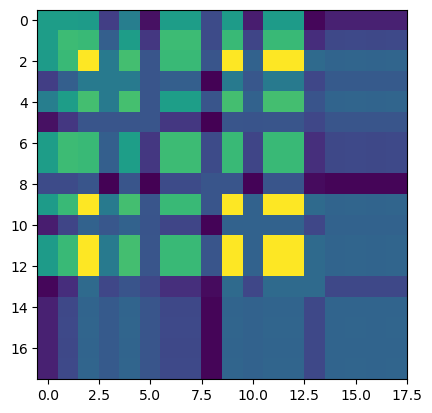

In [70]:
mc_rel = mc_labels[:, high_col].astype(int)
cooc_mat = mc_rel.T @ mc_rel 
# plt.imshow(cooc_mat)
from sklearn.metrics import ConfusionMatrixDisplay
cm_disp = ConfusionMatrixDisplay(cooc_mat, display_labels=[go_terms[i] for i in high_col])
fig, ax = plt.subplots(figsize=(10, 10))
cm_disp.plot(ax=ax)

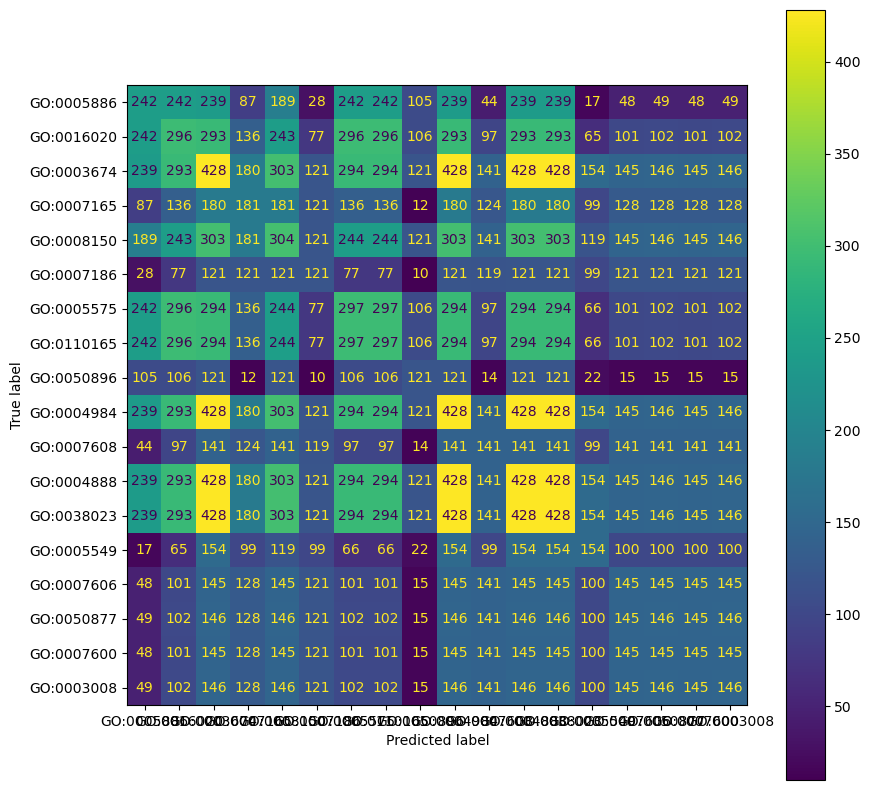

(37708,)